In [31]:
# Auto-install dependencies used in this notebook
# This cell will install packages into the Python interpreter backing the current notebook kernel.
import sys, subprocess

packages = [
    "pyserial",
    "Pillow",
    "ezdxf",
    "matplotlib",
    "scikit-learn",
    "Adafruit-Blinka",
    "adafruit-circuitpython-adxl34x",
    "adafruit-circuitpython-ads1x15",
]

for pkg in packages:
    try:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
    except subprocess.CalledProcessError:
        print(f"Failed to install {pkg}")

print("Dependency installation step complete. Restart kernel if packages were upgraded.")

Installing pyserial...
Installing Pillow...
Installing ezdxf...
Installing matplotlib...
Installing scikit-learn...
Installing Adafruit-Blinka...
Installing adafruit-circuitpython-adxl34x...
Installing adafruit-circuitpython-ads1x15...
Dependency installation step complete. Restart kernel if packages were upgraded.


In [48]:
# Create a minimal measurements.csv used by Chapter 09
import csv
with open('measurements.csv','w',newline='') as f:
    w=csv.writer(f)
    w.writerow(['part_id','feature','measured_value'])
    w.writerow(['P001','bore_diameter','12.001'])
print('wrote measurements.csv')

wrote measurements.csv


In [49]:
# Create a small placeholder image used by Chapter 06
from PIL import Image, ImageDraw
img = Image.new('L', (32,32), color=255)
draw = ImageDraw.Draw(img)
draw.rectangle([8,8,24,24], fill=0)
img.save('your_image.png')
print('wrote your_image.png')

wrote your_image.png


In [50]:
# Create a simple DXF file used by Chapter 06
import ezdxf
doc = ezdxf.new(dxfversion='R2010')
msp = doc.modelspace()
msp.add_line((0,0),(40,0))
msp.add_line((40,0),(40,20))
msp.add_line((40,20),(0,20))
msp.add_line((0,20),(0,0))
doc.saveas('your_shape.dxf')
print('wrote your_shape.dxf')

wrote your_shape.dxf


In [51]:
# Create a minimal SQLite DB for sensor readings (Chapter 13)
import sqlite3
conn = sqlite3.connect('shop_sensors.db')
conn.execute('CREATE TABLE IF NOT EXISTS readings (id INTEGER PRIMARY KEY, timestamp TEXT, vibration REAL, current REAL, temperature REAL)')
conn.commit(); conn.close()
print('wrote shop_sensors.db')

wrote shop_sensors.db


# CNC for Engineers & Operators - Master Code Companion
This notebook contains all executable code snippets from the book, organized sequentially by chapter.
Run cells in order to maintain function states and database configurations across chapters.


---
## 📘 Chapter 01 Operator Track


In [52]:
print("First part of the day. Let's check the setup.")



First part of the day. Let's check the setup.


In [53]:
feed_rate = 300        # in mm/min
spindle_speed = 8500   # in RPM
material = "6061 aluminum"

print("Running job on:", material)
print("Feed rate set to:", feed_rate, "mm/min")
print("Spindle speed set to:", spindle_speed, "RPM")


Running job on: 6061 aluminum
Feed rate set to: 300 mm/min
Spindle speed set to: 8500 RPM


In [54]:
cycle_time_seconds = 45
parts_needed = 120

total_seconds = cycle_time_seconds * parts_needed
total_minutes = total_seconds / 60

print("Total run time in minutes:", total_minutes)


Total run time in minutes: 90.0


In [55]:
measured_diameter = 12.045
tolerance_upper = 12.050
tolerance_lower = 11.950

if measured_diameter > tolerance_upper:
    print("OUT OF SPEC — part is oversized")
elif measured_diameter < tolerance_lower:
    print("OUT OF SPEC — part is undersized")
else:
    print("Part is within tolerance")


Part is within tolerance


In [56]:
number_of_holes = 6

for hole in range(1, number_of_holes + 1):
    print("Drilling hole number", hole)


Drilling hole number 1
Drilling hole number 2
Drilling hole number 3
Drilling hole number 4
Drilling hole number 5
Drilling hole number 6


In [57]:
# Simple batch quality check

measurements = [12.048, 12.052, 11.949, 12.001, 12.061]
tolerance_upper = 12.050
tolerance_lower = 11.950

part_number = 1
for measurement in measurements:
    if measurement > tolerance_upper:
        print("Part", part_number, "- OVERSIZED -", measurement)
    elif measurement < tolerance_lower:
        print("Part", part_number, "- UNDERSIZED -", measurement)
    else:
        print("Part", part_number, "- OK -", measurement)
    part_number = part_number + 1


Part 1 - OK - 12.048
Part 2 - OVERSIZED - 12.052
Part 3 - UNDERSIZED - 11.949
Part 4 - OK - 12.001
Part 5 - OVERSIZED - 12.061



---
## 📘 Chapter 02 Engineer Track


G21          ; use millimeters
G90          ; absolute positioning
G0 X0 Y0 Z5  ; rapid move to start position
G1 Z-2 F100  ; feed down into material
G1 X50 F300  ; cut a straight line to X=50
M5           ; stop spindle
M30          ; end program


In [58]:
gcode_lines = [
    "G21",
    "G90",
    "G0 X0 Y0 Z5",
    "G1 Z-2 F100",
    "G1 X50 F300",
    "M5",
    "M30"
]

feed_rates_found = []

for line in gcode_lines:
    if "F" in line:
        parts = line.split("F")
        feed_value = parts[1].strip()
        feed_rates_found.append(feed_value)

print("Feed rates used in this program:", feed_rates_found)


Feed rates used in this program: ['100', '300']



---
## 📘 Chapter 03 Common Ground


In [59]:
print("Colab is working.")


Colab is working.


In [60]:
feed_rate = 300
print("Feed rate:" + feed_rate)


TypeError: can only concatenate str (not "int") to str

In [ ]:
feed_rate = 300
print("Feed rate:" + str(feed_rate))
  

Feed rate:300



pip install pyserial # Run this command inside your terminal or command prompt if running locally
!pip install pyserial # Run this command inside colab cell if you are using colab

In [ ]:
%pip install pyserial

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import serial
import time

# Update this to match your machine's port
# Windows example: "COM3"    Mac/Linux example: "/dev/ttyUSB0"
port_name = "COM3"
baud_rate = 115200

connection = serial.Serial(port_name, baud_rate, timeout=2)
time.sleep(2)  # GRBL needs a moment to initialize after connecting

connection.write(b"\r\n\r\n")  # wake up GRBL
time.sleep(2)
connection.flushInput()

connection.write(b"?\n")  # ask GRBL for its current status
response = connection.readline()
print("Machine responded:", response)

connection.close()


SerialException: could not open port 'COM3': FileNotFoundError(2, 'The system cannot find the file specified.', None, 2)


---
## 📘 Chapter 04 Reading Writing Gcode


In [ ]:
machine_status = {"spindle": "on", "feed_rate": 300, "tool": 4}
print(machine_status["feed_rate"])   # prints 300


300


In [ ]:
def parse_gcode_line(line):
    """
    Takes one line of G-code and returns a dictionary describing it.
    Handles comments, blank lines, and any combination of parameters.
    """
    # Strip inline comments (anything after a semicolon)
    line = line.split(";")[0].strip()

    if line == "":
        return None  # blank line or comment-only line, nothing to parse

    tokens = line.split()
    parsed = {"command": tokens[0], "params": {}}

    for token in tokens[1:]:
        letter = token[0]
        value = token[1:]
        try:
            parsed["params"][letter] = float(value)
        except ValueError:
            parsed["params"][letter] = value  # non-numeric, keep as text

    return parsed


# Quick test
test_lines = [
    "G1 X50 Y25 F300  ; cutting move",
    "; this whole line is a comment",
    "",
    "G0 Z5",
    "M3 S8500"
]

for line in test_lines:
    result = parse_gcode_line(line)
    print(result)


{'command': 'G1', 'params': {'X': 50.0, 'Y': 25.0, 'F': 300.0}}
None
None
{'command': 'G0', 'params': {'Z': 5.0}}
{'command': 'M3', 'params': {'S': 8500.0}}


In [ ]:
def parse_gcode_program(gcode_text):
    """
    Takes a full G-code program as a multi-line string and returns
    a list of parsed line dictionaries, skipping blanks and comments.
    """
    parsed_lines = []
    for raw_line in gcode_text.strip().split("\n"):
        result = parse_gcode_line(raw_line)
        if result is not None:
            parsed_lines.append(result)
    return parsed_lines


sample_program = """
G21          ; use millimeters
G90          ; absolute positioning
G0 X0 Y0 Z5
G1 Z-2 F100
G1 X50 F300
G1 Y25
M5
M30
"""

program = parse_gcode_program(sample_program)

for line in program:
    print(line)


{'command': 'G21', 'params': {}}
{'command': 'G90', 'params': {}}
{'command': 'G0', 'params': {'X': 0.0, 'Y': 0.0, 'Z': 5.0}}
{'command': 'G1', 'params': {'Z': -2.0, 'F': 100.0}}
{'command': 'G1', 'params': {'X': 50.0, 'F': 300.0}}
{'command': 'G1', 'params': {'Y': 25.0}}
{'command': 'M5', 'params': {}}
{'command': 'M30', 'params': {}}


In [136]:
import sys
print(sys.executable)


f:\Obsidian\.venv\Scripts\python.exe


In [ ]:
def get_all_feed_rates(parsed_program):
    feed_rates = []
    for line in parsed_program:
        if "F" in line["params"]:
            feed_rates.append(line["params"]["F"])
    return feed_rates


def get_max_z_depth(parsed_program):
    z_values = []
    for line in parsed_program:
        if "Z" in line["params"]:
            z_values.append(line["params"]["Z"])
    if z_values:
        return min(z_values)  # most negative Z = deepest cut
    return None


def count_rapid_moves(parsed_program):
    count = 0
    for line in parsed_program:
        if line["command"] == "G0":
            count += 1
    return count


print("Feed rates used:", get_all_feed_rates(program))
print("Deepest Z reached:", get_max_z_depth(program))
print("Number of rapid moves:", count_rapid_moves(program))


Feed rates used: [100.0, 300.0]
Deepest Z reached: -2.0
Number of rapid moves: 1


In [ ]:
def make_gcode_line(command, **params):
    """
    Builds a single G-code line from a command and any number of
    named parameters. Example: make_gcode_line("G1", X=50, F=300)
    """
    parts = [command]
    for letter, value in params.items():
        parts.append(f"{letter}{value}")
    return " ".join(parts)


# Build a few lines
print(make_gcode_line("G0", X=0, Y=0, Z=5))
print(make_gcode_line("G1", Z=-2, F=100))
print(make_gcode_line("G1", X=50, F=300))


G0 X0 Y0 Z5
G1 Z-2 F100
G1 X50 F300


In [ ]:
original_line = "G1 X50 Y25 F300"

parsed = parse_gcode_line(original_line)
regenerated = make_gcode_line(parsed["command"], **parsed["params"])

print("Original:   ", original_line)
print("Regenerated:", regenerated)


Original:    G1 X50 Y25 F300
Regenerated: G1 X50.0 Y25.0 F300.0



---
## 📘 Chapter 05 Gcode Generator


In [ ]:
import math

def make_gcode_line(command, **params):
    parts = [command]
    for letter, value in params.items():
        parts.append(f"{letter}{value}")
    return " ".join(parts)


def bolt_circle(center_x, center_y, radius, num_holes,
                 safe_z=5, drill_z=-5, feed=100):
    """
    Generates a full G-code program that drills num_holes evenly
    spaced around a circle of the given radius, centered at
    (center_x, center_y).
    """
    lines = []
    lines.append(make_gcode_line("G21"))          # millimeters
    lines.append(make_gcode_line("G90"))           # absolute positioning
    lines.append(make_gcode_line("G0", Z=safe_z))  # start at a safe height

    for i in range(num_holes):
        angle = 2 * math.pi * i / num_holes
        x = round(center_x + radius * math.cos(angle), 3)
        y = round(center_y + radius * math.sin(angle), 3)

        lines.append(make_gcode_line("G0", X=x, Y=y))       # move above hole
        lines.append(make_gcode_line("G1", Z=drill_z, F=feed))  # plunge
        lines.append(make_gcode_line("G0", Z=safe_z))       # retract

    lines.append(make_gcode_line("M30"))  # end of program
    return lines


# Generate a 6-hole bolt circle, 40mm diameter (20mm radius), centered at origin
program = bolt_circle(center_x=0, center_y=0, radius=20, num_holes=6)

for line in program:
    print(line)


G21
G90
G0 Z5
G0 X20.0 Y0.0
G1 Z-5 F100
G0 Z5
G0 X10.0 Y17.321
G1 Z-5 F100
G0 Z5
G0 X-10.0 Y17.321
G1 Z-5 F100
G0 Z5
G0 X-20.0 Y0.0
G1 Z-5 F100
G0 Z5
G0 X-10.0 Y-17.321
G1 Z-5 F100
G0 Z5
G0 X10.0 Y-17.321
G1 Z-5 F100
G0 Z5
M30


In [ ]:
def hole_grid(start_x, start_y, columns, rows, spacing_x, spacing_y,
              safe_z=5, drill_z=-5, feed=100):
    """
    Generates a full G-code program that drills a grid of holes:
    'columns' holes across, 'rows' holes down, starting at
    (start_x, start_y), spaced spacing_x apart horizontally and
    spacing_y apart vertically.
    """
    lines = []
    lines.append(make_gcode_line("G21"))
    lines.append(make_gcode_line("G90"))
    lines.append(make_gcode_line("G0", Z=safe_z))

    for row in range(rows):
        for col in range(columns):
            x = start_x + col * spacing_x
            y = start_y + row * spacing_y

            lines.append(make_gcode_line("G0", X=x, Y=y))
            lines.append(make_gcode_line("G1", Z=drill_z, F=feed))
            lines.append(make_gcode_line("G0", Z=safe_z))

    lines.append(make_gcode_line("M30"))
    return lines


# Generate a 3x2 grid of holes, 20mm apart in both directions
grid_program = hole_grid(start_x=0, start_y=0, columns=3, rows=2,
                          spacing_x=20, spacing_y=20)

for line in grid_program:
    print(line)


G21
G90
G0 Z5
G0 X0 Y0
G1 Z-5 F100
G0 Z5
G0 X20 Y0
G1 Z-5 F100
G0 Z5
G0 X40 Y0
G1 Z-5 F100
G0 Z5
G0 X0 Y20
G1 Z-5 F100
G0 Z5
G0 X20 Y20
G1 Z-5 F100
G0 Z5
G0 X40 Y20
G1 Z-5 F100
G0 Z5
M30


In [ ]:
def drill_at(x, y, safe_z=5, drill_z=-5, feed=100):
    """
    Returns the G-code lines for drilling a single hole at (x, y):
    move above it, plunge to depth, retract to safe height.
    """
    return [
        make_gcode_line("G0", X=round(x, 3), Y=round(y, 3)),
        make_gcode_line("G1", Z=drill_z, F=feed),
        make_gcode_line("G0", Z=safe_z),
    ]


def bolt_circle_v2(center_x, center_y, radius, num_holes,
                    safe_z=5, drill_z=-5, feed=100):
    lines = [make_gcode_line("G21"), make_gcode_line("G90"),
             make_gcode_line("G0", Z=safe_z)]

    for i in range(num_holes):
        angle = 2 * math.pi * i / num_holes
        x = center_x + radius * math.cos(angle)
        y = center_y + radius * math.sin(angle)
        lines.extend(drill_at(x, y, safe_z, drill_z, feed))

    lines.append(make_gcode_line("M30"))
    return lines


def hole_grid_v2(start_x, start_y, columns, rows, spacing_x, spacing_y,
                  safe_z=5, drill_z=-5, feed=100):
    lines = [make_gcode_line("G21"), make_gcode_line("G90"),
             make_gcode_line("G0", Z=safe_z)]

    for row in range(rows):
        for col in range(columns):
            x = start_x + col * spacing_x
            y = start_y + row * spacing_y
            lines.extend(drill_at(x, y, safe_z, drill_z, feed))

    lines.append(make_gcode_line("M30"))
    return lines


# Confirm both still produce correct output
for line in bolt_circle_v2(0, 0, 20, 6):
    print(line)
print("---")
for line in hole_grid_v2(0, 0, 3, 2, 20, 20):
    print(line)


G21
G90
G0 Z5
G0 X20.0 Y0.0
G1 Z-5 F100
G0 Z5
G0 X10.0 Y17.321
G1 Z-5 F100
G0 Z5
G0 X-10.0 Y17.321
G1 Z-5 F100
G0 Z5
G0 X-20.0 Y0.0
G1 Z-5 F100
G0 Z5
G0 X-10.0 Y-17.321
G1 Z-5 F100
G0 Z5
G0 X10.0 Y-17.321
G1 Z-5 F100
G0 Z5
M30
---
G21
G90
G0 Z5
G0 X0 Y0
G1 Z-5 F100
G0 Z5
G0 X20 Y0
G1 Z-5 F100
G0 Z5
G0 X40 Y0
G1 Z-5 F100
G0 Z5
G0 X0 Y20
G1 Z-5 F100
G0 Z5
G0 X20 Y20
G1 Z-5 F100
G0 Z5
G0 X40 Y20
G1 Z-5 F100
G0 Z5
M30



---
## 📘 Chapter 06 Image Dxf To Gcode


In [ ]:
!pip install Pillow

  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl (7.2 MB)


In [137]:
from PIL import Image

def make_gcode_line(command, **params):
    parts = [command]
    for letter, value in params.items():
        parts.append(f"{letter}{value}")
    return " ".join(parts)


def drill_at(x, y, safe_z=5, drill_z=-1, feed=100):
    return [
        make_gcode_line("G0", X=round(x, 3), Y=round(y, 3)),
        make_gcode_line("G1", Z=drill_z, F=feed),
        make_gcode_line("G0", Z=safe_z),
    ]


def image_to_gcode(image_path, pixel_size_mm=1.0, threshold=128,
                    safe_z=5, drill_z=-1, feed=100):
    """
    Converts a grayscale image into an engraving G-code program.
    Every pixel darker than 'threshold' becomes one engraved point,
    spaced pixel_size_mm apart on the machine.
    """
    img = Image.open(image_path).convert("L")  # "L" = grayscale mode
    width, height = img.size
    pixels = img.load()

    lines = [make_gcode_line("G21"), make_gcode_line("G90"),
             make_gcode_line("G0", Z=safe_z)]

    points_engraved = 0
    for row in range(height):
        for col in range(width):
            brightness = pixels[col, row]
            if brightness < threshold:
                x = col * pixel_size_mm
                y = (height - row) * pixel_size_mm
                lines.extend(drill_at(x, y, safe_z, drill_z, feed))
                points_engraved += 1

    lines.append(make_gcode_line("M30"))
    return lines, points_engraved


program, count = image_to_gcode("your_image.png", pixel_size_mm=1.0)
print("Points that will be engraved:", count)
for line in program[:15]:
    print(line)


Points that will be engraved: 289
G21
G90
G0 Z5
G0 X8.0 Y24.0
G1 Z-1 F100
G0 Z5
G0 X9.0 Y24.0
G1 Z-1 F100
G0 Z5
G0 X10.0 Y24.0
G1 Z-1 F100
G0 Z5
G0 X11.0 Y24.0
G1 Z-1 F100
G0 Z5


In [138]:
!pip install ezdxf 

In [139]:
import ezdxf
import math

def dxf_to_gcode(dxf_path, safe_z=5, cut_z=-2, feed=200):
    """
    Reads a DXF file and converts LINE and CIRCLE entities into
    G-code cutting moves. Lines become a single straight cut;
    circles are traced as a loop of short straight segments.
    """
    doc = ezdxf.readfile(dxf_path)
    msp = doc.modelspace()

    lines = [make_gcode_line("G21"), make_gcode_line("G90"),
             make_gcode_line("G0", Z=safe_z)]

    shapes_processed = 0
    for entity in msp:
        if entity.dxftype() == "LINE":
            start = entity.dxf.start
            end = entity.dxf.end
            lines.append(make_gcode_line("G0", X=round(start.x, 3), Y=round(start.y, 3)))
            lines.append(make_gcode_line("G1", Z=cut_z, F=feed))
            lines.append(make_gcode_line("G1", X=round(end.x, 3), Y=round(end.y, 3), F=feed))
            lines.append(make_gcode_line("G0", Z=safe_z))
            shapes_processed += 1

        elif entity.dxftype() == "CIRCLE":
            center = entity.dxf.center
            radius = entity.dxf.radius
            segments = 36  # approximate the circle with 36 short straight cuts
            start_x = center.x + radius
            start_y = center.y
            lines.append(make_gcode_line("G0", X=round(start_x, 3), Y=round(start_y, 3)))
            lines.append(make_gcode_line("G1", Z=cut_z, F=feed))
            for i in range(1, segments + 1):
                angle = 2 * math.pi * i / segments
                x = center.x + radius * math.cos(angle)
                y = center.y + radius * math.sin(angle)
                lines.append(make_gcode_line("G1", X=round(x, 3), Y=round(y, 3), F=feed))
            lines.append(make_gcode_line("G0", Z=safe_z))
            shapes_processed += 1

    lines.append(make_gcode_line("M30"))
    return lines, shapes_processed


program, count = dxf_to_gcode("your_shape.dxf")
print("Shapes processed:", count)
for line in program:
    print(line)


Shapes processed: 4
G21
G90
G0 Z5
G0 X0.0 Y0.0
G1 Z-2 F200
G1 X40.0 Y0.0 F200
G0 Z5
G0 X40.0 Y0.0
G1 Z-2 F200
G1 X40.0 Y20.0 F200
G0 Z5
G0 X40.0 Y20.0
G1 Z-2 F200
G1 X0.0 Y20.0 F200
G0 Z5
G0 X0.0 Y20.0
G1 Z-2 F200
G1 X0.0 Y0.0 F200
G0 Z5
M30



---
## 📘 Chapter 07 Gcode Viewer


In [150]:
import matplotlib.pyplot as plt
import re

def parse_gcode_program(gcode_text):
    """
    Helper function to parse raw G-code text into a clean list of dictionaries.
    """
    parsed_lines = []
    for line in gcode_text.strip().split("\n"):
        # Strip comments starting with ; or enclosed in ()
        line = re.sub(r";.*|\(.*?\)", "", line).strip()
        if not line:
            continue
            
        parts = line.split()
        command = parts[0].upper()
        params = {}
        
        for part in parts[1:]:
            match = re.match(r"([A-Za-z])([-+]?\d*\.\d+|\d+)", part)
            if match:
                axis, value = match.groups()
                params[axis.upper()] = float(value)
                
        parsed_lines.append({"command": command, "params": params})
    return parsed_lines

def view_gcode(gcode_text, title="Toolpath Preview", save_path="gcode_preview_1.png"):
    """
    Parses a G-code program and plots its XY toolpath.
    """
    program = parse_gcode_program(gcode_text)

    current_x, current_y = 0.0, 0.0
    rapid_segments = []
    cut_segments = []

    for line in program:
        command = line["command"]
        params = line["params"]

        if command not in ("G0", "G1"):
            continue 

        new_x = params.get("X", current_x)
        new_y = params.get("Y", current_y)

        if command == "G0":
            rapid_segments.append(((current_x, current_y), (new_x, new_y)))
        elif command == "G1":
            cut_segments.append(((current_x, current_y), (new_x, new_y)))

        current_x, current_y = new_x, new_y

    fig, ax = plt.subplots(figsize=(6, 6))

    # Plot rapid moves (dashed gray)
    for (x1, y1), (x2, y2) in rapid_segments:
        ax.plot([x1, x2], [y1, y2], linestyle="--", color="gray", linewidth=1)

    # Plot cutting moves (solid blue)
    for (x1, y1), (x2, y2) in cut_segments:
        ax.plot([x1, x2], [y1, y2], linestyle="-", color="blue", linewidth=2)

    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xlabel("X (mm)")
    ax.set_ylabel("Y (mm)")

    # Save the file locally so Obsidian can display the image matrix
    plt.savefig(save_path, dpi=100)
    plt.close() # Close plot to free up memory
    
    print(f"Success! Rapid segments: {len(rapid_segments)}, Cut segments: {len(cut_segments)}")
    print(f"Image saved as: {save_path}")

# --- SAMPLE TEST RUN ---
# Here is some basic G-code creating a small square toolpath
example_gcode = """
G0 X0 Y0
G1 X50 Y0
G1 X50 Y50
G1 X0 Y50
G1 X0 Y0
G0 X10 Y10
"""

view_gcode(example_gcode,save_path="gcode_preview_2.png")

   


Success! Rapid segments: 2, Cut segments: 4
Image saved as: gcode_preview_2.png


In [153]:
program_lines = bolt_circle(center_x=0, center_y=0, radius=20, num_holes=6)
gcode_text = "\n".join(program_lines)

#  run the below code if you are running python locally
view_gcode(gcode_text, title="6-Hole Bolt Circle") 

# hash the previous line delete the # in the next line if you are running  colab
#view_gcode(gcode_text, title="6-Hole Bolt Circle", save_path="/content/sample_data/gcode_preview.png")

# The view_gcode function currently prints the counts directly and returns None.



Success! Rapid segments: 13, Cut segments: 6
Image saved as: gcode_preview_1.png


In [154]:
program_lines, shape_count = dxf_to_gcode("your_shape.dxf")
gcode_text = "\n".join(program_lines)
view_gcode(gcode_text, title="Rectangle + Circle From DXF")
#print("Rapid segments:", rapid_count)
#print("Cutting segments:", cut_count)



Success! Rapid segments: 9, Cut segments: 8
Image saved as: gcode_preview_1.png



---
## 📘 Chapter 08 Auto Logging


In [155]:
import datetime

right_now = datetime.datetime.now()
print(right_now)


2026-09-11 11:20:23.601083


In [67]:
import datetime

def start_job_log(job_name):
    """
    Records the start of a job. Returns a dictionary representing
    this job's in-progress record.
    """
    return {
        "job_name": job_name,
        "start_time": datetime.datetime.now(),
        "end_time": None,
    }


def end_job_log(job_record, parts_completed):
    """
    Fills in the end time and part count on an existing job record,
    and calculates how long the job took.
    """
    job_record["end_time"] = datetime.datetime.now()
    job_record["parts_completed"] = parts_completed

    duration = job_record["end_time"] - job_record["start_time"]
    job_record["duration_seconds"] = duration.total_seconds()

    return job_record


# Simulate a job by starting the log, waiting a moment, then ending it
import time

job = start_job_log("Bracket-Rev4")
time.sleep(2)  # stand-in for the job actually running
job = end_job_log(job, parts_completed=5)

print(job)


{'job_name': 'Bracket-Rev4', 'start_time': datetime.datetime(2026, 9, 10, 19, 2, 26, 889928), 'end_time': datetime.datetime(2026, 9, 10, 19, 2, 28, 890547), 'parts_completed': 5, 'duration_seconds': 2.000619}


In [68]:
import csv
import os

LOG_FILE = "job_log.csv"

def save_job_log(job_record, log_file=LOG_FILE):
    """
    Appends one finished job record as a new row in the log file.
    Writes a header row automatically the first time the file is created.
    """
    file_already_exists = os.path.isfile(log_file)

    with open(log_file, "a", newline="") as f:
        writer = csv.writer(f)

        if not file_already_exists:
            writer.writerow(["job_name", "start_time", "end_time",
                              "duration_seconds", "parts_completed"])

        writer.writerow([
            job_record["job_name"],
            job_record["start_time"].isoformat(),
            job_record["end_time"].isoformat(),
            round(job_record["duration_seconds"], 2),
            job_record["parts_completed"],
        ])


save_job_log(job)
print("Saved. Contents of the log file:")
with open(LOG_FILE) as f:
    print(f.read())


Saved. Contents of the log file:
job_name,start_time,end_time,duration_seconds,parts_completed
Bracket-Rev4,2026-09-10T19:02:26.889928,2026-09-10T19:02:28.890547,2.0,5



In [156]:
def load_job_log(log_file=LOG_FILE):
    """
    Reads the CSV log back into a list of dictionaries, converting
    the numeric columns back from text into real numbers.
    """
    jobs = []
    with open(log_file, "r", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            row["duration_seconds"] = float(row["duration_seconds"])
            row["parts_completed"] = int(row["parts_completed"])
            jobs.append(row)
    return jobs


def summarize_jobs(jobs):
    """Returns overall totals across every logged job."""
    total_parts = sum(j["parts_completed"] for j in jobs)
    total_time = sum(j["duration_seconds"] for j in jobs)
    avg_time = total_time / len(jobs) if jobs else 0

    return {
        "total_jobs": len(jobs),
        "total_parts": total_parts,
        "total_time_seconds": round(total_time, 2),
        "avg_time_per_job": round(avg_time, 2),
    }


jobs = load_job_log()
print("Summary across all logged jobs:")
print(summarize_jobs(jobs))


Summary across all logged jobs:
{'total_jobs': 1, 'total_parts': 5, 'total_time_seconds': 2.0, 'avg_time_per_job': 2.0}


In [70]:
def summarize_by_job_name(jobs):
    """Groups logged jobs by name and totals parts made for each."""
    breakdown = {}

    for job in jobs:
        name = job["job_name"]
        if name not in breakdown:
            breakdown[name] = {"count": 0, "total_parts": 0}
        breakdown[name]["count"] += 1
        breakdown[name]["total_parts"] += job["parts_completed"]

    return breakdown


print("Breakdown by job name:")
print(summarize_by_job_name(jobs))


Breakdown by job name:
{'Bracket-Rev4': {'count': 1, 'total_parts': 5}}



---
## 📘 Chapter 09 Quality Checks


In [157]:
TOLERANCES = {
    "bore_diameter": {"nominal": 12.000, "upper": 12.050, "lower": 11.950},
    "hole_3_depth":  {"nominal": 5.000,  "upper": 5.050,  "lower": 4.950},
}


In [158]:
import csv

def load_measurements(csv_path):
    """
    Reads a measurement CSV into a list of dictionaries, converting
    the measured_value column from text back into a real number.
    """
    measurements = []
    with open(csv_path, "r", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            row["measured_value"] = float(row["measured_value"])
            measurements.append(row)
    return measurements


data = load_measurements("measurements.csv")
for row in data:
    print(row)


{'part_id': 'P001', 'feature': 'bore_diameter', 'measured_value': 12.001}


In [159]:
def check_measurement(feature, measured_value, tolerances=TOLERANCES):
    """
    Compares a single measured value against the tolerance defined
    for its feature, and returns a plain-text status.
    """
    if feature not in tolerances:
        return "UNKNOWN FEATURE"

    spec = tolerances[feature]

    if measured_value > spec["upper"]:
        return "OVERSIZED"
    elif measured_value < spec["lower"]:
        return "UNDERSIZED"
    else:
        return "OK"


In [160]:
def run_quality_check(csv_path, tolerances=TOLERANCES):
    """
    Loads every measurement from a CSV file and checks each one
    against its feature's tolerance, returning a full list of results.
    """
    measurements = load_measurements(csv_path)
    results = []

    for m in measurements:
        status = check_measurement(m["feature"], m["measured_value"], tolerances)
        results.append({
            "part_id": m["part_id"],
            "feature": m["feature"],
            "measured_value": m["measured_value"],
            "status": status,
        })

    return results


results = run_quality_check("measurements.csv")
for r in results:
    print(r)

fail_count = sum(1 for r in results if r["status"] != "OK")
print("Total measurements checked:", len(results))
print("Total failed:", fail_count)


{'part_id': 'P001', 'feature': 'bore_diameter', 'measured_value': 12.001, 'status': 'OK'}
Total measurements checked: 1
Total failed: 0


In [161]:
def save_quality_report(results, output_path="quality_report.csv"):
    """Writes the full list of check results to a CSV file."""
    with open(output_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["part_id", "feature", "measured_value", "status"])
        writer.writeheader()
        for r in results:
            writer.writerow(r)


def which_parts_failed(results):
    """Returns the set of part_ids that had at least one failing measurement."""
    failed_parts = set()
    for r in results:
        if r["status"] != "OK":
            failed_parts.add(r["part_id"])
    return failed_parts


save_quality_report(results)
failed = which_parts_failed(results)
print("Parts needing attention:", sorted(failed))


Parts needing attention: []



---
## 📘 Chapter 10 Serial Streaming


In [162]:
class MockGRBL:
    """
    Simulates just enough of a GRBL controller's serial behavior to
    test streaming logic: it acknowledges each line with 'ok', and
    can be told to simulate an error on a specific line number.
    """
    def __init__(self, error_on_line=None):
        self.lines_received = []
        self.error_on_line = error_on_line
        self._line_count = 0

    def write(self, data):
        text = data.decode().strip()
        if text:
            self.lines_received.append(text)
            self._line_count += 1

    def readline(self):
        if self.error_on_line is not None and self._line_count == self.error_on_line:
            return b"error:20\r\n"
        return b"ok\r\n"

    def flushInput(self):
        pass

    def close(self):
        pass


In [163]:
import time

def stream_gcode(connection, gcode_lines, wait_between_lines=0.0):
    """
    Sends a list of G-code lines one at a time over an open connection,
    waiting for the controller to acknowledge each one with 'ok' before
    sending the next. Stops immediately if the controller reports an error.
    Returns True if the entire program streamed successfully, False if
    it was stopped early.
    """
    for line_number, line in enumerate(gcode_lines, start=1):
        connection.write((line + "\n").encode())

        response = connection.readline().decode().strip()

        if response.startswith("error"):
            print(f"STOPPED at line {line_number} ({line}): controller reported {response}")
            return False

        print(f"Line {line_number}/{len(gcode_lines)} sent: {line} -> {response}")
        time.sleep(wait_between_lines)

    print("Program complete — all lines acknowledged.")
    return True


In [164]:
# Test 1: a normal, successful stream
test_program = ["G21", "G90", "G0 X0 Y0", "G1 X10 F100", "M30"]

mock = MockGRBL()
success = stream_gcode(mock, test_program)

print("Completed successfully:", success)
print("Lines the mock controller actually received:", mock.lines_received)


Line 1/5 sent: G21 -> ok
Line 2/5 sent: G90 -> ok
Line 3/5 sent: G0 X0 Y0 -> ok
Line 4/5 sent: G1 X10 F100 -> ok
Line 5/5 sent: M30 -> ok
Program complete — all lines acknowledged.
Completed successfully: True
Lines the mock controller actually received: ['G21', 'G90', 'G0 X0 Y0', 'G1 X10 F100', 'M30']


In [165]:
# Test 2: simulate an error on line 3 - does streaming actually stop?
mock_with_error = MockGRBL(error_on_line=3)
success = stream_gcode(mock_with_error, test_program)

print("Completed successfully:", success)
print("Lines actually sent before stopping:", mock_with_error.lines_received)


Line 1/5 sent: G21 -> ok
Line 2/5 sent: G90 -> ok
STOPPED at line 3 (G0 X0 Y0): controller reported error:20
Completed successfully: False
Lines actually sent before stopping: ['G21', 'G90', 'G0 X0 Y0']


In [166]:
def clean_gcode_for_streaming(raw_gcode_text):
    """
    Takes raw G-code text — possibly with comments and blank lines —
    and returns a clean list of just the lines that should actually
    be sent to the controller.
    """
    clean_lines = []
    for raw_line in raw_gcode_text.strip().split("\n"):
        stripped = raw_line.split(";")[0].strip()
        if stripped:
            clean_lines.append(stripped)
    return clean_lines


sample_raw_program = """
G21          ; use millimeters
G90          ; absolute positioning

G0 X0 Y0 Z5
G1 Z-2 F100
M30
"""

ready_to_stream = clean_gcode_for_streaming(sample_raw_program)
print(ready_to_stream)


['G21', 'G90', 'G0 X0 Y0 Z5', 'G1 Z-2 F100', 'M30']


In [167]:
import serial

port_name = "COM3"  # update to match your machine — see Chapter 3
baud_rate = 115200

connection = serial.Serial(port_name, baud_rate, timeout=5)
time.sleep(2)  # let GRBL finish initializing
connection.write(b"\r\n\r\n")
time.sleep(2)
connection.flushInput()

gcode_to_run = clean_gcode_for_streaming(sample_raw_program)
success = stream_gcode(connection, gcode_to_run, wait_between_lines=0.05)

connection.close()


SerialException: could not open port 'COM3': FileNotFoundError(2, 'The system cannot find the file specified.', None, 2)


---
## 📘 Chapter 11 Batch Automation


In [82]:
import time
import datetime
import csv
import os

# --- From Chapter 10 ---
class MockGRBL:
    def __init__(self, error_on_line=None):
        self.lines_received = []
        self.error_on_line = error_on_line
        self._line_count = 0

    def write(self, data):
        text = data.decode().strip()
        if text:
            self.lines_received.append(text)
            self._line_count += 1

    def readline(self):
        if self.error_on_line is not None and self._line_count == self.error_on_line:
            return b"error:20\r\n"
        return b"ok\r\n"

    def flushInput(self):
        pass

    def close(self):
        pass


def stream_gcode(connection, gcode_lines, wait_between_lines=0.0):
    for line_number, line in enumerate(gcode_lines, start=1):
        connection.write((line + "\n").encode())
        response = connection.readline().decode().strip()
        if response.startswith("error"):
            print(f"STOPPED at line {line_number} ({line}): controller reported {response}")
            return False
        print(f"Line {line_number}/{len(gcode_lines)} sent: {line} -> {response}")
        time.sleep(wait_between_lines)
    print("Program complete — all lines acknowledged.")
    return True


# --- From Chapter 8 ---
def start_job_log(job_name):
    return {"job_name": job_name, "start_time": datetime.datetime.now(), "end_time": None}


def end_job_log(job_record, parts_completed, outcome="completed"):
    job_record["end_time"] = datetime.datetime.now()
    job_record["parts_completed"] = parts_completed
    job_record["outcome"] = outcome
    duration = job_record["end_time"] - job_record["start_time"]
    job_record["duration_seconds"] = duration.total_seconds()
    return job_record


def save_job_log(job_record, log_file="batch_log.csv"):
    file_already_exists = os.path.isfile(log_file)
    with open(log_file, "a", newline="") as f:
        writer = csv.writer(f)
        if not file_already_exists:
            writer.writerow(["job_name", "start_time", "end_time",
                              "duration_seconds", "parts_completed", "outcome"])
        writer.writerow([
            job_record["job_name"], job_record["start_time"].isoformat(),
            job_record["end_time"].isoformat(), round(job_record["duration_seconds"], 2),
            job_record["parts_completed"], job_record["outcome"],
        ])


In [168]:
jobs = [
    {"name": "Bracket-Rev4", "gcode": ["G21", "G90", "G0 X0 Y0", "M30"], "expected_parts": 5},
    {"name": "Housing-A",    "gcode": ["G21", "G90", "G0 X10 Y0", "M30"], "expected_parts": 3},
    {"name": "Shaft-Coupler","gcode": ["G21", "G90", "G0 X20 Y0", "M30"], "expected_parts": 8},
]


In [84]:
import datetime

def notify(message, alerts_file="alerts.log"):
    """
    Records a notification: prints it immediately and appends it to
    a permanent alerts log file, timestamped.
    """
    timestamp = datetime.datetime.now().isoformat()
    full_message = f"[{timestamp}] {message}"
    print("ALERT:", full_message)
    with open(alerts_file, "a") as f:
        f.write(full_message + "\n")


In [169]:
def run_batch(connection, jobs, stop_on_error=True):
    """
    Runs a queue of jobs one after another. Each job is a dictionary
    with 'name', 'gcode', and 'expected_parts'. Logs every job and
    sends a notification if a job fails to complete. If stop_on_error
    is True, the batch halts on the first failure; if False, it
    continues on to the remaining jobs.
    """
    results = []

    for job in jobs:
        print(f"--- Starting job: {job['name']} ---")
        log = start_job_log(job["name"])

        success = stream_gcode(connection, job["gcode"])

        if success:
            log = end_job_log(log, parts_completed=job["expected_parts"], outcome="completed")
        else:
            log = end_job_log(log, parts_completed=0, outcome="failed")
            notify(f"Job '{job['name']}' failed to complete — machine reported an error.")

        save_job_log(log)
        results.append(log)

        if not success and stop_on_error:
            notify(f"Batch stopped after failure on '{job['name']}'.")
            break

    return results


In [170]:
mock = MockGRBL(error_on_line=6)  # fails on the 2nd line of Housing-A (job 1 has 4 lines)

results = run_batch(mock, jobs, stop_on_error=True)

for r in results:
    print(r["job_name"], r["outcome"], r["parts_completed"])


--- Starting job: Bracket-Rev4 ---
Line 1/4 sent: G21 -> ok
Line 2/4 sent: G90 -> ok
Line 3/4 sent: G0 X0 Y0 -> ok
Line 4/4 sent: M30 -> ok
Program complete — all lines acknowledged.
--- Starting job: Housing-A ---
Line 1/4 sent: G21 -> ok
STOPPED at line 2 (G90): controller reported error:20
ALERT: [2026-09-11T11:21:38.160543] Job 'Housing-A' failed to complete — machine reported an error.
ALERT: [2026-09-11T11:21:38.163390] Batch stopped after failure on 'Housing-A'.
Bracket-Rev4 completed 5
Housing-A failed 0


In [171]:
mock2 = MockGRBL(error_on_line=6)

results2 = run_batch(mock2, jobs, stop_on_error=False)

for r in results2:
    print(r["job_name"], r["outcome"], r["parts_completed"])


--- Starting job: Bracket-Rev4 ---
Line 1/4 sent: G21 -> ok
Line 2/4 sent: G90 -> ok
Line 3/4 sent: G0 X0 Y0 -> ok
Line 4/4 sent: M30 -> ok
Program complete — all lines acknowledged.
--- Starting job: Housing-A ---
Line 1/4 sent: G21 -> ok
STOPPED at line 2 (G90): controller reported error:20
ALERT: [2026-09-11T11:21:40.856782] Job 'Housing-A' failed to complete — machine reported an error.
--- Starting job: Shaft-Coupler ---
Line 1/4 sent: G21 -> ok
Line 2/4 sent: G90 -> ok
Line 3/4 sent: G0 X20 Y0 -> ok
Line 4/4 sent: M30 -> ok
Program complete — all lines acknowledged.
Bracket-Rev4 completed 5
Housing-A failed 0
Shaft-Coupler completed 8



---
## 📘 Chapter 12 Sensors


In [172]:
import random

def simulate_vibration_reading(baseline=0.05, chatter_chance=0.05, chatter_magnitude=0.6):
    """
    Simulates one accelerometer reading in g's from a running spindle.
    Most readings are small noise around a baseline; occasionally,
    controlled by chatter_chance, a much larger spike is simulated,
    standing in for real chatter or an impact.
    """
    noise = random.uniform(-baseline, baseline)
    reading = baseline + noise

    if random.random() < chatter_chance:
        reading += chatter_magnitude

    return round(reading, 4)


def simulate_sensor_stream(num_readings=20, chatter_chance=0.05):
    """Generates a list of simulated vibration readings."""
    readings = []
    for i in range(num_readings):
        readings.append(simulate_vibration_reading(chatter_chance=chatter_chance))
    return readings


random.seed(42)  # makes the "random" results repeatable for testing
stream = simulate_sensor_stream(num_readings=20, chatter_chance=0.15)
print(stream)
print("Max reading:", max(stream))
print("Likely chatter events (above 0.3):", [r for r in stream if r > 0.3])


[0.6639, 0.0275, 0.0736, 0.6892, 0.6422, 0.0219, 0.0027, 0.065, 0.022, 0.6809, 0.0806, 0.034, 0.0957, 0.6093, 0.0847, 0.0807, 0.0536, 0.0379, 0.0829, 0.0862]
Max reading: 0.6892
Likely chatter events (above 0.3): [0.6639, 0.6892, 0.6422, 0.6809, 0.6093]


In [173]:
import random
def simulate_spindle_current(idle_current=0.5, cutting_current=2.5, is_cutting=True, noise=0.1):
    """
    Simulates one current sensor reading in amps. Idle draws much
    less current than actively cutting; noise represents normal
    motor and sensor fluctuation.
    """
    base = cutting_current if is_cutting else idle_current
    return round(base + random.uniform(-noise, noise), 3)


def simulate_temperature(drift_per_reading=0.05, current_temp=22.0):
    """
    Simulates one temperature reading in Celsius, drifting slightly
    upward from the previous reading, plus small random noise.
    """
    new_temp = current_temp + drift_per_reading + random.uniform(-0.05, 0.05)
    return round(new_temp, 2)


print("Spindle current while cutting:",
      [simulate_spindle_current(is_cutting=True) for _ in range(5)])
print("Spindle current while idle:",
      [simulate_spindle_current(is_cutting=False) for _ in range(5)])

# Temperature needs to track its own previous value to drift realistically
temp = 22.0
temperature_log = []
for _ in range(10):
    temp = simulate_temperature(current_temp=temp)
    temperature_log.append(temp)

print("Temperature drift over 10 readings:", temperature_log)


Spindle current while cutting: [2.541, 2.409, 2.446, 2.458, 2.416]
Spindle current while idle: [0.447, 0.42, 0.456, 0.527, 0.473]
Temperature drift over 10 readings: [22.04, 22.06, 22.09, 22.18, 22.24, 22.3, 22.32, 22.39, 22.41, 22.45]



---
## 📘 Chapter 13 Raspberry Pi Hub


In [174]:
# Template — requires a real Raspberry Pi, real ADXL345 hardware,
# and the adafruit-circuitpython-adxl34x library (pip install).
# Not verified against physical hardware for this book.

import board
import busio
import adafruit_adxl34x

i2c = busio.I2C(board.SCL, board.SDA)
accelerometer = adafruit_adxl34x.ADXL345(i2c)

x, y, z = accelerometer.acceleration  # in meters per second squared
print("Acceleration:", x, y, z)


NotImplementedError: 
                adafruit-platformdetect version 3.89.1 was unable to identify the board
                and/or microcontroller running the Windows platform.
                Please be sure you have the latest packages by running:
                'pip3 install --upgrade adafruit-blinka adafruit-platformdetect'

                If you are running the latest package, your board may not yet be supported. Please
                open a New Issue on GitHub at https://github.com/adafruit/Adafruit_Blinka/issues and
                select New Board Request.
                

In [175]:
# Template — requires an ADS1115 ADC, an ACS712 current sensor,
# correct wiring, and calibration specific to your exact sensor.
# Not verified against physical hardware for this book.

import board
import busio
import adafruit_ads1x15.ads1115 as ADS
from adafruit_ads1x15.analog_in import AnalogIn

i2c = busio.I2C(board.SCL, board.SDA)
ads = ADS.ADS1115(i2c)
channel = AnalogIn(ads, ADS.P0)

voltage = channel.voltage
# Converting voltage to actual current requires your specific sensor's
# datasheet formula — this varies by sensor model and must be calibrated.
print("Raw voltage reading:", voltage)


NotImplementedError: 
                adafruit-platformdetect version 3.89.1 was unable to identify the board
                and/or microcontroller running the Windows platform.
                Please be sure you have the latest packages by running:
                'pip3 install --upgrade adafruit-blinka adafruit-platformdetect'

                If you are running the latest package, your board may not yet be supported. Please
                open a New Issue on GitHub at https://github.com/adafruit/Adafruit_Blinka/issues and
                select New Board Request.
                

In [176]:
def read_sensors(use_simulation=True):
    """
    Reads one set of sensor values: vibration, current, temperature.
    If use_simulation is True, generates realistic fake data (Chapter 12).
    If False, this is where real hardware-reading code from Section 13.3
    would go instead, once you've adapted it to your specific sensors.
    """
    if use_simulation:
        return {
            "vibration": simulate_vibration_reading(),
            "current": simulate_spindle_current(is_cutting=True),
            "temperature": simulate_temperature(),
        }
    else:
        raise NotImplementedError(
            "Real hardware reading requires adapting Section 13.3's "
            "template to your specific sensors first."
        )


In [177]:
import sqlite3

def create_sensor_database(db_path="shop_sensors.db"):
    """Creates the sensor readings table if it doesn't already exist."""
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS readings (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            timestamp TEXT,
            vibration REAL,
            current REAL,
            temperature REAL
        )
    """)
    conn.commit()
    conn.close()


In [178]:
import datetime

def save_reading(vibration, current, temperature, db_path="shop_sensors.db"):
    """Inserts one new sensor reading into the database, timestamped now."""
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    cursor.execute(
        "INSERT INTO readings (timestamp, vibration, current, temperature) VALUES (?, ?, ?, ?)",
        (datetime.datetime.now().isoformat(), vibration, current, temperature)
    )
    conn.commit()
    conn.close()


In [179]:
import time

def monitor_loop(num_readings=10, interval_seconds=1.0, use_simulation=True):
    """
    Reads sensors repeatedly, logging each reading to the database,
    pausing interval_seconds between each one.
    """
    for i in range(num_readings):
        reading = read_sensors(use_simulation=use_simulation)
        save_reading(reading["vibration"], reading["current"], reading["temperature"])
        time.sleep(interval_seconds)

    print(f"Logged {num_readings} readings.")


create_sensor_database()
monitor_loop(num_readings=10, interval_seconds=0.5)


Logged 10 readings.


In [180]:
def load_recent_readings(limit=50, db_path="shop_sensors.db"):
    """Returns the most recent readings, oldest first."""
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    cursor.execute(
        "SELECT timestamp, vibration, current, temperature FROM readings ORDER BY id DESC LIMIT ?",
        (limit,)
    )
    rows = cursor.fetchall()
    conn.close()
    rows.reverse()  # DESC gave us newest-first; reverse for a natural timeline
    return rows


def average_reading(column, db_path="shop_sensors.db"):
    """Computes the average value of one sensor column across all logged readings."""
    if column not in ("vibration", "current", "temperature"):
        raise ValueError(f"Unknown column: {column}")

    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    cursor.execute(f"SELECT AVG({column}) FROM readings")
    result = cursor.fetchone()[0]
    conn.close()

    return round(result, 4) if result is not None else None


recent = load_recent_readings(limit=5)
for row in recent:
    print(row)

print("Average vibration:", average_reading("vibration"))
print("Average current:", average_reading("current"))


('2026-09-11T11:22:25.615543', 0.0561, 2.517, 22.09)
('2026-09-11T11:22:26.224318', 0.0399, 2.6, 22.05)
('2026-09-11T11:22:26.823815', 0.6091, 2.422, 22.06)
('2026-09-11T11:22:27.373085', 0.0792, 2.413, 22.04)
('2026-09-11T11:22:27.942031', 0.0996, 2.594, 22.09)
Average vibration: 0.0567
Average current: 2.5038



---
## 📘 Chapter 14 Live Dashboard


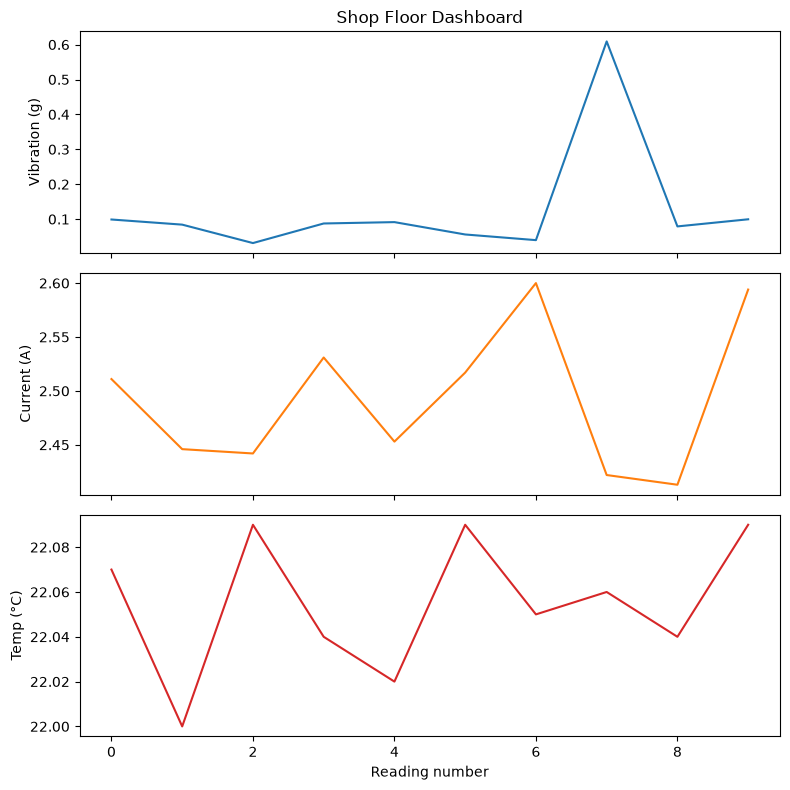

In [181]:
import matplotlib.pyplot as plt

def plot_dashboard(rows, save_path=None):
    """
    Plots vibration, current, and temperature as three stacked panels
    sharing the same horizontal axis, from a list of database rows
    shaped like (timestamp, vibration, current, temperature).
    """
    vibration = [r[1] for r in rows]
    current = [r[2] for r in rows]
    temperature = [r[3] for r in rows]
    x = list(range(len(rows)))  # reading number, simpler to read than full timestamps

    fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

    axes[0].plot(x, vibration, color="tab:blue")
    axes[0].set_ylabel("Vibration (g)")
    axes[0].set_title("Shop Floor Dashboard")

    axes[1].plot(x, current, color="tab:orange")
    axes[1].set_ylabel("Current (A)")

    axes[2].plot(x, temperature, color="tab:red")
    axes[2].set_ylabel("Temp (°C)")
    axes[2].set_xlabel("Reading number")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=100)
    plt.show()


rows = load_recent_readings(limit=10)  # from Chapter 13
plot_dashboard(rows)


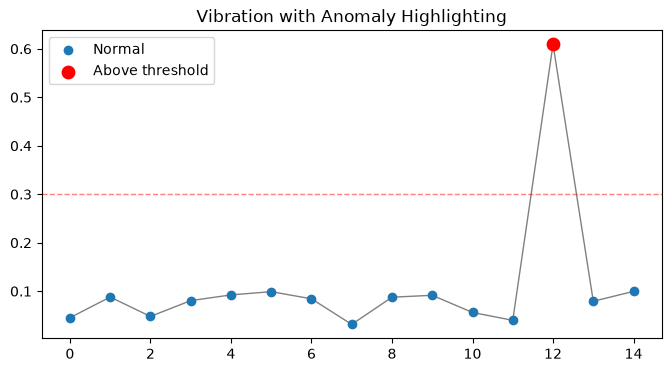

Number of readings above threshold: 1


In [182]:
def plot_with_alerts(rows, vibration_limit=0.3, save_path=None):
    """
    Plots vibration over time, highlighting any reading above
    vibration_limit in red, with a dashed line marking the limit itself.
    """
    x = list(range(len(rows)))
    vibration = [r[1] for r in rows]

    normal_x = [xi for xi, v in zip(x, vibration) if v <= vibration_limit]
    normal_y = [v for v in vibration if v <= vibration_limit]
    alert_x = [xi for xi, v in zip(x, vibration) if v > vibration_limit]
    alert_y = [v for v in vibration if v > vibration_limit]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(x, vibration, color="gray", linewidth=1, zorder=1)
    ax.scatter(normal_x, normal_y, color="tab:blue", zorder=2, label="Normal")
    ax.scatter(alert_x, alert_y, color="red", zorder=3, label="Above threshold", s=80)
    ax.axhline(vibration_limit, color="red", linestyle="--", linewidth=1, alpha=0.5)

    ax.set_title("Vibration with Anomaly Highlighting")
    ax.legend()

    if save_path:
        plt.savefig(save_path, dpi=100)
    plt.show()

    return len(alert_x)


rows = load_recent_readings(limit=15)
alert_count = plot_with_alerts(rows)
print("Number of readings above threshold:", alert_count)


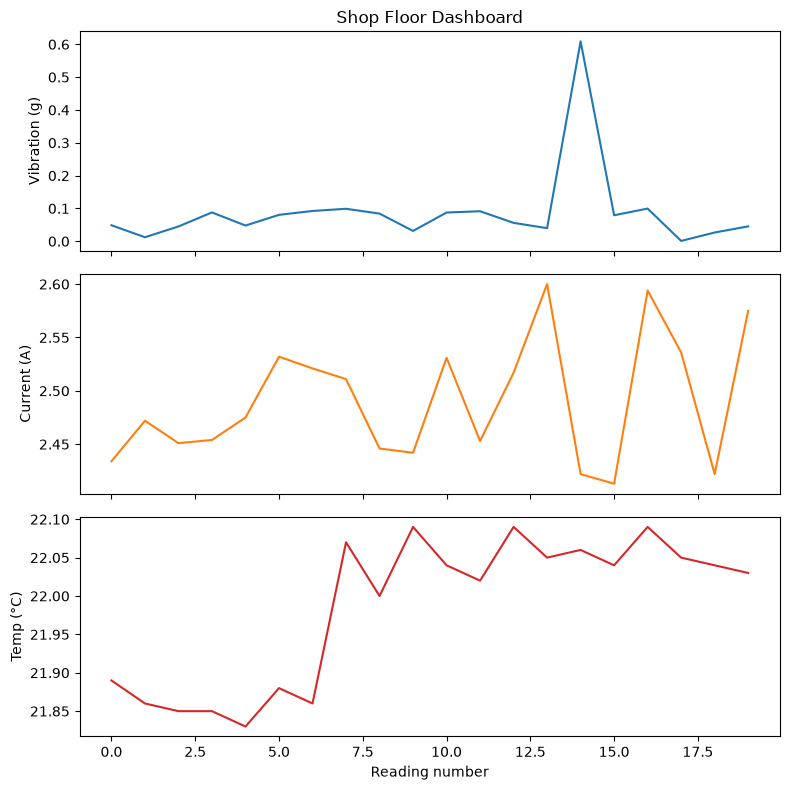

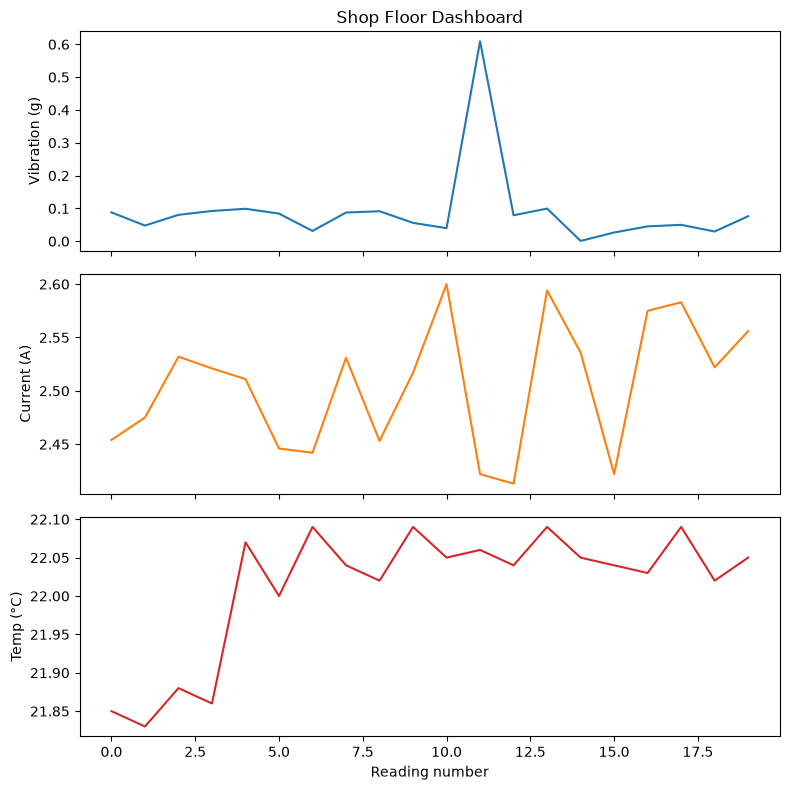

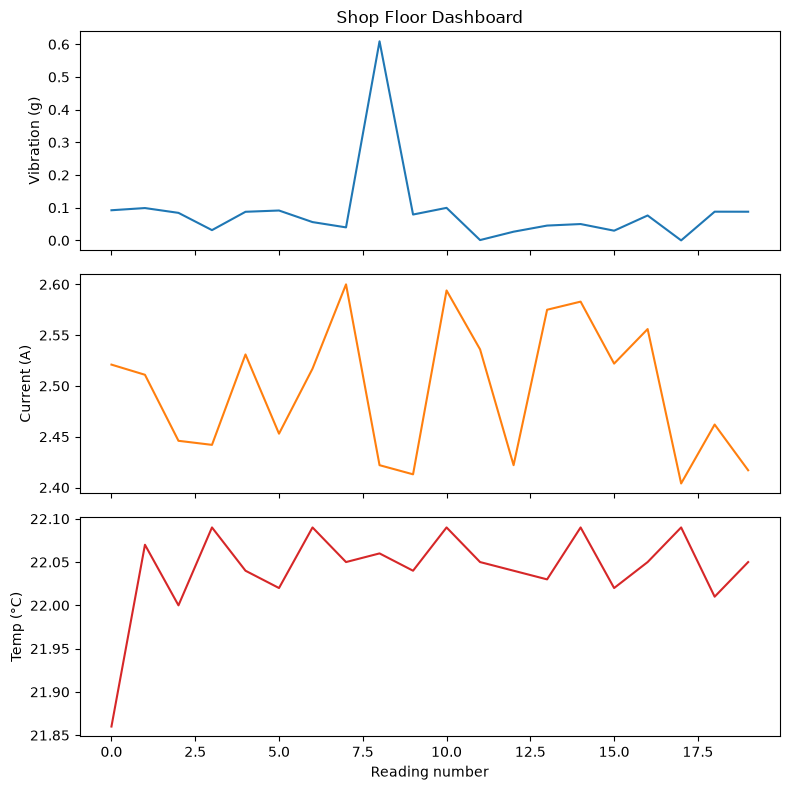

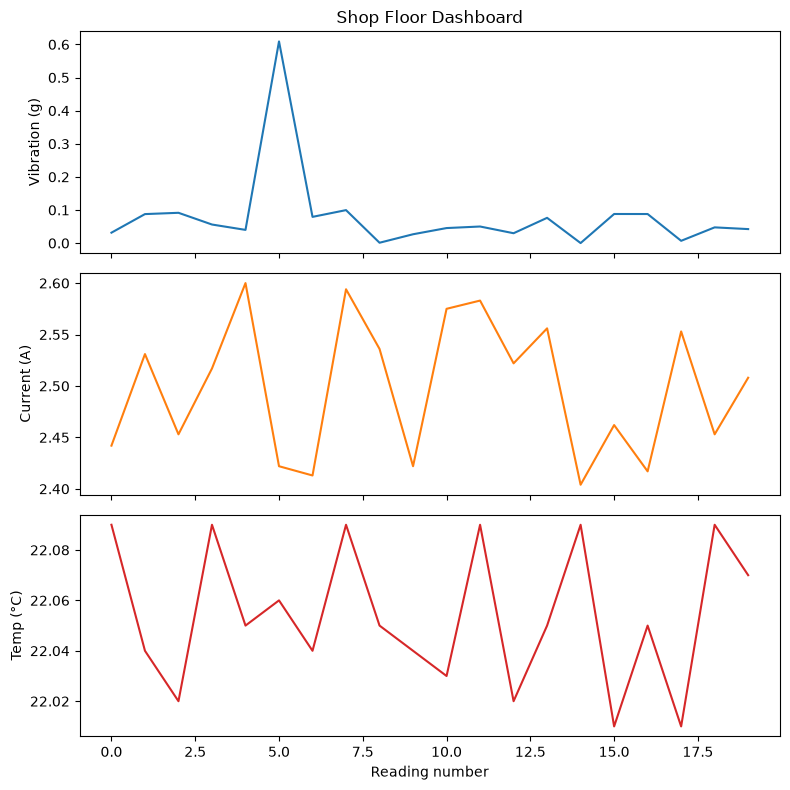

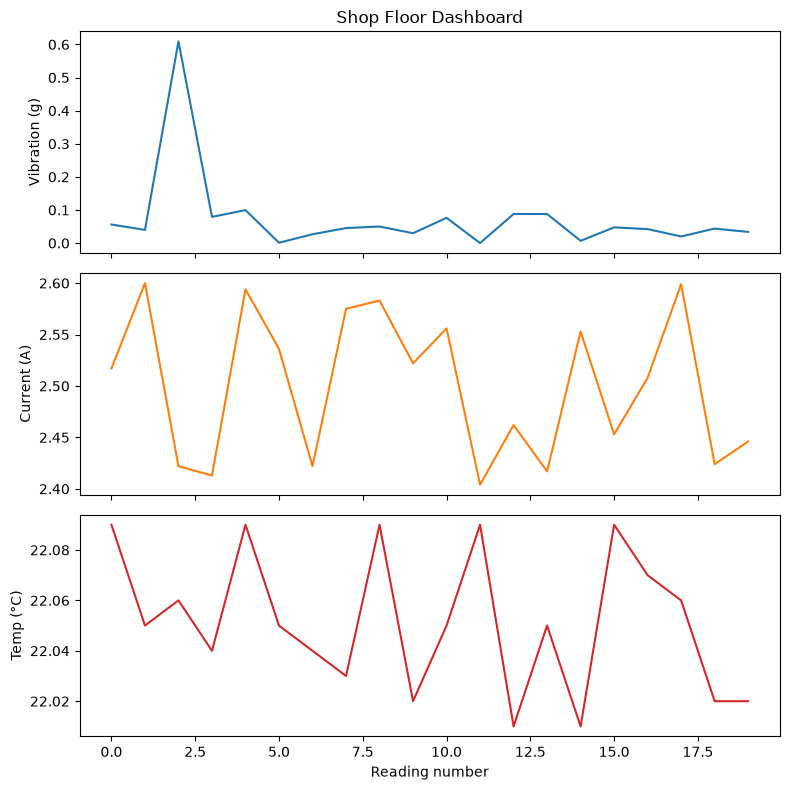

In [183]:
import time

def live_dashboard_loop(num_refreshes=20, readings_per_refresh=3,
                          window_size=30, pause_seconds=1.0, use_simulation=True):
    """
    Continuously takes new sensor readings, saves them to the database,
    and redraws the dashboard from the most recent window_size readings.
    """
    for refresh in range(num_refreshes):
        for _ in range(readings_per_refresh):
            reading = read_sensors(use_simulation=use_simulation)  # Chapter 13
            save_reading(reading["vibration"], reading["current"], reading["temperature"])

        rows = load_recent_readings(limit=window_size)
        plot_dashboard(rows)

        time.sleep(pause_seconds)


live_dashboard_loop(num_refreshes=5, readings_per_refresh=3, window_size=20, pause_seconds=0.5)



---
## 📘 Chapter 15 No Deep Learning Needed


In [185]:
import random

def simulate_vibration_reading(baseline=0.05, chatter_chance=0.05, chatter_magnitude=0.6):
    noise = random.uniform(-baseline, baseline)
    reading = baseline + noise
    if random.random() < chatter_chance:
        reading += chatter_magnitude
    return round(reading, 4)


# A noisier machine's genuinely normal operation — no chatter simulated at all
random.seed(30)
noisier_machine_normal = [simulate_vibration_reading(baseline=0.17, chatter_chance=0.0) for _ in range(200)]

fixed_threshold = 0.3
false_alarms = [v for v in noisier_machine_normal if v > fixed_threshold]

print("Readings during genuinely normal operation:", len(noisier_machine_normal))
print("How many the fixed threshold incorrectly flagged:", len(false_alarms))


Readings during genuinely normal operation: 200
How many the fixed threshold incorrectly flagged: 13


In [186]:
import statistics

def learn_threshold(normal_readings, num_std_devs=3):
    """
    Calculates a threshold from a set of known-good readings: the
    average, plus a number of standard deviations above it. Values
    beyond this are unusual relative to this specific dataset's own
    normal behavior, not some borrowed, arbitrary number.
    """
    mean_val = statistics.mean(normal_readings)
    stdev_val = statistics.stdev(normal_readings)
    return mean_val + num_std_devs * stdev_val


learned = learn_threshold(noisier_machine_normal)
print("Mean vibration during normal operation:", round(statistics.mean(noisier_machine_normal), 4))
print("Standard deviation:", round(statistics.stdev(noisier_machine_normal), 4))
print("Learned threshold (mean + 3 standard deviations):", round(learned, 4))


Mean vibration during normal operation: 0.1605
Standard deviation: 0.0956
Learned threshold (mean + 3 standard deviations): 0.4473


In [187]:
learned_false_alarms = [v for v in noisier_machine_normal if v > learned]
print("Learned threshold false alarms on this machine's own normal data:", len(learned_false_alarms))


Learned threshold false alarms on this machine's own normal data: 0


In [188]:
# A stream from the same noisier machine, now including some real chatter events
test_stream = [simulate_vibration_reading(baseline=0.17, chatter_chance=0.1, chatter_magnitude=0.25)
               for _ in range(100)]

fixed_flags = [v for v in test_stream if v > fixed_threshold]
learned_flags = [v for v in test_stream if v > learned]

print("Fixed threshold (0.3) flagged:", len(fixed_flags), "readings")
print("Learned threshold flagged:", len(learned_flags), "readings")

# Which readings did the fixed threshold flag that the learned threshold correctly recognized as normal?
false_positives = [v for v in fixed_flags if v <= learned]
print("Values the fixed threshold got wrong (false alarms):", sorted(false_positives))


Fixed threshold (0.3) flagged: 22 readings
Learned threshold flagged: 6 readings
Values the fixed threshold got wrong (false alarms): [0.3099, 0.3103, 0.3128, 0.3135, 0.3166, 0.3168, 0.3197, 0.3201, 0.3312, 0.3331, 0.3362, 0.3366, 0.3383, 0.355, 0.3855, 0.3927]



---
## 📘 Chapter 16 Anomaly Detector


In [189]:
import random
import statistics
import sqlite3
import datetime
import os

# --- From Chapter 12 ---
def simulate_vibration_reading(baseline=0.05, chatter_chance=0.05, chatter_magnitude=0.6):
    noise = random.uniform(-baseline, baseline)
    reading = baseline + noise
    if random.random() < chatter_chance:
        reading += chatter_magnitude
    return round(reading, 4)


def simulate_spindle_current(idle_current=0.5, cutting_current=2.5, is_cutting=True, noise=0.1):
    base = cutting_current if is_cutting else idle_current
    return round(base + random.uniform(-noise, noise), 3)


_last_temp = {"value": 22.0}
def simulate_temperature(drift_per_reading=0.0):
    _last_temp["value"] += drift_per_reading + random.uniform(-0.05, 0.05)
    return round(_last_temp["value"], 2)


def read_sensors(use_simulation=True):
    if use_simulation:
        return {
            "vibration": simulate_vibration_reading(),
            "current": simulate_spindle_current(is_cutting=True),
            "temperature": simulate_temperature(),
        }
    else:
        raise NotImplementedError("Real hardware requires Chapter 13's Section 13.3 setup.")


# --- From Chapter 13 ---
def create_sensor_database(db_path="shop_sensors.db"):
    conn = sqlite3.connect(db_path)
    conn.execute("""
        CREATE TABLE IF NOT EXISTS readings (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            timestamp TEXT, vibration REAL, current REAL, temperature REAL
        )
    """)
    conn.commit()
    conn.close()


def save_reading(vibration, current, temperature, db_path="shop_sensors.db"):
    conn = sqlite3.connect(db_path)
    conn.execute(
        "INSERT INTO readings (timestamp, vibration, current, temperature) VALUES (?, ?, ?, ?)",
        (datetime.datetime.now().isoformat(), vibration, current, temperature)
    )
    conn.commit()
    conn.close()


def load_recent_readings(limit=50, db_path="shop_sensors.db"):
    conn = sqlite3.connect(db_path)
    rows = conn.execute(
        "SELECT timestamp, vibration, current, temperature FROM readings ORDER BY id DESC LIMIT ?",
        (limit,)
    ).fetchall()
    conn.close()
    rows.reverse()
    return rows


# --- From Chapter 11 ---
def notify(message, alerts_file="alerts.log"):
    timestamp = datetime.datetime.now().isoformat()
    full_message = f"[{timestamp}] {message}"
    print("ALERT:", full_message)
    with open(alerts_file, "a") as f:
        f.write(full_message + "\n")


In [125]:
def learn_thresholds(normal_readings_by_sensor, num_std_devs=3):
    """
    Learns a threshold for each sensor independently, from a dictionary
    of known-good readings shaped like:
    {"vibration": [...], "current": [...], "temperature": [...]}
    Returns a dictionary of learned thresholds, one entry per sensor.
    """
    thresholds = {}
    for sensor_name, readings in normal_readings_by_sensor.items():
        mean_val = statistics.mean(readings)
        stdev_val = statistics.stdev(readings)
        thresholds[sensor_name] = {
            "mean": mean_val,
            "stdev": stdev_val,
            "upper_limit": mean_val + num_std_devs * stdev_val,
        }
    return thresholds


In [190]:
def check_reading(reading, thresholds):
    """
    Checks one reading (a dict like {"vibration": 0.6, "current": 2.5,
    "temperature": 22.1}) against learned thresholds. Returns a list
    of sensor names that are currently anomalous — empty if none are.
    """
    anomalies = []
    for sensor_name, value in reading.items():
        if sensor_name not in thresholds:
            continue  # no learned threshold for this sensor yet
        if value > thresholds[sensor_name]["upper_limit"]:
            anomalies.append(sensor_name)
    return anomalies


In [191]:
# Build thresholds from a quick calibration sample
random.seed(50)
normal_vibration = [simulate_vibration_reading(chatter_chance=0.0) for _ in range(200)]
normal_current = [simulate_spindle_current(is_cutting=True) for _ in range(200)]
thresholds = learn_thresholds({"vibration": normal_vibration, "current": normal_current})

print("Normal reading:", check_reading({"vibration": 0.05, "current": 2.5}, thresholds))
print("High vibration only:", check_reading({"vibration": 0.7, "current": 2.5}, thresholds))
print("Both high:", check_reading({"vibration": 0.7, "current": 5.0}, thresholds))


Normal reading: []
High vibration only: ['vibration']
Both high: ['vibration', 'current']


In [192]:
def calibrate_from_database(db_path="shop_sensors.db", limit=200, num_std_devs=3):
    """
    Learns thresholds directly from a machine's own recently logged
    data. Assumes the readings passed in represent genuinely normal
    operation — see the warning in Section 16.6 about what happens
    if that assumption is wrong.
    """
    rows = load_recent_readings(limit=limit, db_path=db_path)
    normal_data = {
        "vibration": [r[1] for r in rows],
        "current": [r[2] for r in rows],
        "temperature": [r[3] for r in rows],
    }
    return learn_thresholds(normal_data, num_std_devs=num_std_devs)


In [193]:
def monitor_with_detection(thresholds, num_readings=20, use_simulation=True):
    """
    Reads sensors repeatedly, logs every reading, checks each one for
    anomalies against the given thresholds, and notifies immediately
    if anything is flagged. Returns how many readings were flagged.
    """
    flagged_count = 0
    for i in range(num_readings):
        reading = read_sensors(use_simulation=use_simulation)
        save_reading(reading["vibration"], reading["current"], reading["temperature"])

        anomalies = check_reading(reading, thresholds)
        if anomalies:
            flagged_count += 1
            notify(f"Anomaly detected in: {', '.join(anomalies)} — reading: {reading}")

    return flagged_count


In [194]:
create_sensor_database()

# Step 1: log 200 readings of genuinely normal operation (no chatter)
for _ in range(200):
    v = simulate_vibration_reading(chatter_chance=0.0)
    c = simulate_spindle_current(is_cutting=True)
    t = simulate_temperature(drift_per_reading=0.0)
    save_reading(v, c, t)

# Step 2: calibrate thresholds directly from that logged data
thresholds = calibrate_from_database(limit=200)
for sensor, t in thresholds.items():
    print(sensor, "-> upper limit:", round(t["upper_limit"], 4))

# Step 3: monitor new readings (this time allowing real chatter events)
# Reseeding here only so this example's output is reproducible for you —
# a real monitoring run wouldn't do this, since real sensor data isn't seeded.
random.seed(6)
flagged = monitor_with_detection(thresholds, num_readings=30)
print("\nReadings flagged as anomalous:", flagged, "out of 30")


vibration -> upper limit: 0.1378
current -> upper limit: 2.6753
temperature -> upper limit: 22.1237
ALERT: [2026-09-11T11:23:40.033574] Anomaly detected in: vibration — reading: {'vibration': 0.6698, 'current': 2.556, 'temperature': 21.84}

Readings flagged as anomalous: 1 out of 30


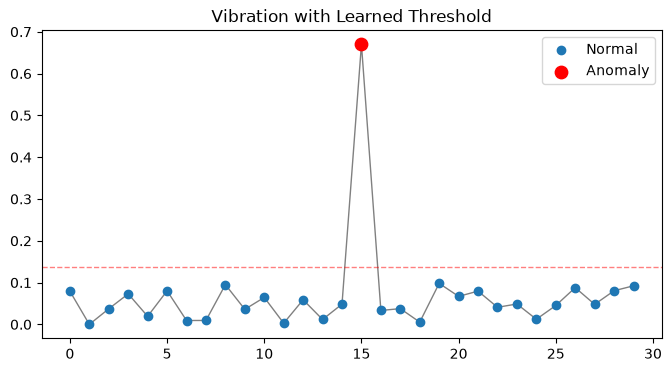

1

In [196]:
import matplotlib.pyplot as plt

def plot_with_learned_threshold(rows, sensor_index, sensor_name, threshold, save_path=None):
    """
    Plots one sensor's recent values, highlighting any reading above
    its learned threshold in red. sensor_index matches load_recent_readings'
    row order: 0=timestamp, 1=vibration, 2=current, 3=temperature.
    """
    x = list(range(len(rows)))
    values = [r[sensor_index] for r in rows]

    normal_x = [xi for xi, v in zip(x, values) if v <= threshold]
    normal_y = [v for v in values if v <= threshold]
    alert_x = [xi for xi, v in zip(x, values) if v > threshold]
    alert_y = [v for v in values if v > threshold]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(x, values, color="gray", linewidth=1, zorder=1)
    ax.scatter(normal_x, normal_y, color="tab:blue", zorder=2, label="Normal")
    ax.scatter(alert_x, alert_y, color="red", zorder=3, label="Anomaly", s=80)
    ax.axhline(threshold, color="red", linestyle="--", linewidth=1, alpha=0.5)

    ax.set_title(f"{sensor_name} with Learned Threshold")
    ax.legend()
    if save_path:
        plt.savefig(save_path, dpi=100)
    plt.show()

    return len(alert_x)


rows = load_recent_readings(limit=30)
plot_with_learned_threshold(rows, sensor_index=1, sensor_name="Vibration",
                              threshold=thresholds["vibration"]["upper_limit"])



---
## 📘 Chapter 17 Tool Wear And When To Use Ml


In [132]:
import random

def simulate_session(is_worn):
    """
    Simulates one cutting session's average vibration (g) and average
    current (A). Worn tools run somewhat higher on both, but with
    realistic overlap — this isn't a clean, artificial separation.
    """
    if is_worn:
        avg_vibration = random.gauss(0.22, 0.07)
        avg_current = random.gauss(2.9, 0.3)
    else:
        avg_vibration = random.gauss(0.09, 0.05)
        avg_current = random.gauss(2.5, 0.25)
    return [max(0, avg_vibration), max(0, avg_current)]


random.seed(42)
X = []  # each entry: [avg_vibration, avg_current]
y = []  # each entry: 0 = sharp tool, 1 = worn tool

for _ in range(150):
    X.append(simulate_session(is_worn=False))
    y.append(0)
for _ in range(150):
    X.append(simulate_session(is_worn=True))
    y.append(1)


In [133]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

model = LogisticRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print("Test set size:", len(y_test))
print("Accuracy:", round(accuracy, 3))
print("Confusion matrix:\n", confusion_matrix(y_test, predictions))


Test set size: 90
Accuracy: 0.767
Confusion matrix:
 [[39  4]
 [17 30]]


In [134]:
import statistics

# Chapter 15-style: a threshold using vibration alone
vibration_only_normal = [x[0] for x, label in zip(X_train, y_train) if label == 0]
vib_threshold = statistics.mean(vibration_only_normal) + 3 * statistics.stdev(vibration_only_normal)

single_variable_predictions = [1 if x[0] > vib_threshold else 0 for x in X_test]
single_variable_accuracy = accuracy_score(y_test, single_variable_predictions)

print("Two-feature classifier accuracy:", round(accuracy, 3))
print("Vibration-only threshold accuracy:", round(single_variable_accuracy, 3))


Two-feature classifier accuracy: 0.767
Vibration-only threshold accuracy: 0.611


In [197]:
# Train 20 different models, each on a fresh, small (10-example) dataset,
# and evaluate every one against the SAME large, realistic test set.
eval_rng_X, eval_rng_y = X_test, y_test  # reuse the larger test set as a stable benchmark

results = []
for seed in range(20):
    rng = random.Random(seed)
    small_X, small_y = [], []

    def sim(is_worn):
        if is_worn:
            return [max(0, rng.gauss(0.22, 0.07)), max(0, rng.gauss(2.9, 0.3))]
        return [max(0, rng.gauss(0.09, 0.05)), max(0, rng.gauss(2.5, 0.25))]

    for _ in range(5):
        small_X.append(sim(False)); small_y.append(0)
    for _ in range(5):
        small_X.append(sim(True)); small_y.append(1)

    small_model = LogisticRegression()
    small_model.fit(small_X, small_y)
    acc = accuracy_score(eval_rng_y, small_model.predict(eval_rng_X))
    results.append(acc)

print("Accuracy across 20 different 10-example training sets:")
print([round(r, 2) for r in results])
print("Range:", round(max(results) - min(results), 2))


Accuracy across 20 different 10-example training sets:
[0.73, 0.71, 0.66, 0.83, 0.72, 0.68, 0.72, 0.7, 0.67, 0.72, 0.7, 0.73, 0.7, 0.71, 0.71, 0.66, 0.82, 0.7, 0.67, 0.69]
Range: 0.18
